# Flow Matching

## Implementing Flow Matching

In [1]:
import numpy as np

class GaussianMixture:
    def __init__(self, parameters):
        self.parameters = parameters
        self.distributions = [
            {
                'mean': np.array(dist['mean']),
                'std': np.array(dist['std']),
                'cov': np.diag(np.array(dist['std']) ** 2)
            }
            for dist in parameters
        ]

    def sample(self, num_samples):
        samples = []
        num_distributions = len(self.distributions)
        for _ in range(num_samples):
            idx = np.random.randint(num_distributions)  # Choose a random Gaussian
            dist = self.distributions[idx]
            sample = np.random.multivariate_normal(mean=dist['mean'], cov=dist['cov'])
            samples.append(sample)
        return np.array(samples)

    def likelihood(self, points):
        likelihoods = np.zeros(points.shape[0])
        for dist in self.distributions:
            mean = dist['mean']
            cov = dist['cov']
            inv_cov = np.linalg.inv(cov)
            det_cov = np.linalg.det(cov)

            # Multivariate Gaussian PDF
            factor = 1 / (2 * np.pi * np.sqrt(det_cov))
            diff = points - mean
            exponents = -0.5 * np.sum(diff @ inv_cov * diff, axis=1)
            likelihoods += factor * np.exp(exponents)

        return likelihoods

## Visualize the data

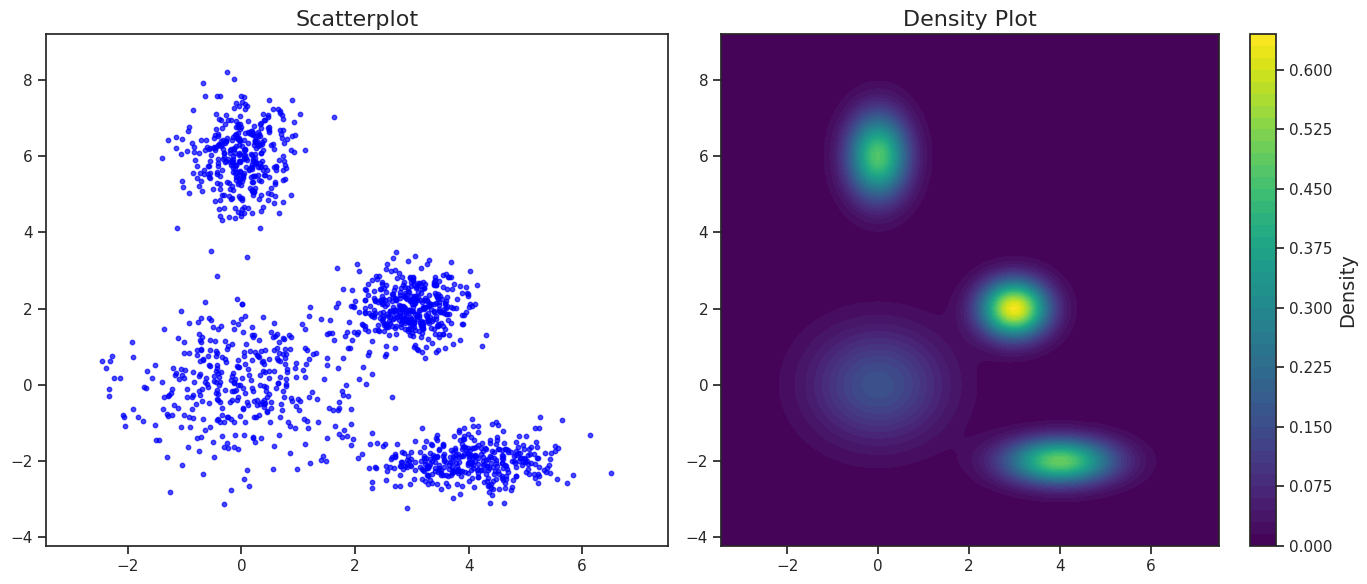

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="ticks")

def plot_gaussian_mixture(gm, samples, grid_size=100):

    x_min, x_max = np.min(samples[:, 0]) - 1, np.max(samples[:, 0]) + 1
    y_min, y_max = np.min(samples[:, 1]) - 1, np.max(samples[:, 1]) + 1
    x = np.linspace(x_min, x_max, grid_size)
    y = np.linspace(y_min, y_max, grid_size)
    X, Y = np.meshgrid(x, y)
    points = np.column_stack([X.ravel(), Y.ravel()])
    densities = gm.likelihood(points).reshape(grid_size, grid_size)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax1 = axes[0]
    ax1.scatter(samples[:, 0], samples[:, 1], s=10, alpha=0.7, color="blue")
    ax1.set_title("Scatterplot", fontsize=16)
    ax1.set_xlim(x_min, x_max)
    ax1.set_ylim(y_min, y_max)

    ax2 = axes[1]
    contour = ax2.contourf(X, Y, densities, cmap="viridis", levels=50)
    cbar = fig.colorbar(contour, ax=ax2)
    cbar.set_label("Density", fontsize=14)
    ax2.set_title("Density Plot", fontsize=16)
    ax2.set_xlim(x_min, x_max)
    ax2.set_ylim(y_min, y_max)

    plt.tight_layout()
    plt.show()

parameters = [
    {"mean": [0, 0], "std": [1, 1]},
    {"mean": [3, 2], "std": [0.5, 0.5]},
    {"mean": [0,6], "std": [0.45,0.75]},
    {"mean": [4,-2], "std": [0.8,0.4]},
]

mixture = GaussianMixture(parameters)
samples = mixture.sample(1500)
plot_gaussian_mixture(mixture, samples)

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class FlowMatchingDataset(Dataset):
    def __init__(self, mixture, n_samples=1000, sigma_min=1e-4):
        super().__init__()
        self.n_samples = n_samples
        self.mixture = mixture
        self.sigma_min = sigma_min
        self.x1 = mixture.sample(n_samples)

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):

        x0 = np.random.multivariate_normal([0.0, 0.0], np.eye(2), 1)[0]
        t = np.random.rand()  # scalar in [0,1]
        x1 = self.x1[idx]

        x_t = (1 - ( 1 - self.sigma_min) * t) * x0 + t * x1
        u_t = (x1 - x0)
        x_t = torch.tensor(x_t, dtype=torch.float32)
        t = torch.tensor([t], dtype=torch.float32)
        u_t = torch.tensor(u_t, dtype=torch.float32)

        return x_t, t, u_t

In [4]:
class VelocityNet(nn.Module):
    def __init__(self, in_dim=2, time_dim=1, hidden_dim=128, out_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim + time_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, x, t):
        xt = torch.cat([x, t], dim=1)
        return self.net(xt)

## Training a Velocity Model

In [5]:
n_samples = 10000
batch_size = 128
n_epochs = 50
learning_rate = 1e-3

dataset = FlowMatchingDataset(mixture, n_samples=n_samples)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

model = VelocityNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.MSELoss()

for epoch in range(n_epochs):
    running_loss = 0.0
    for x_t, t, u_t in dataloader:
        x_t = x_t.to(device)
        t = t.to(device)
        u_t = u_t.to(device)
        optimizer.zero_grad()
        pred_v = model(x_t, t)
        loss = criterion(pred_v, u_t)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x_t.size(0)
    running_loss /= len(dataset)
    print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {running_loss:.4f}")

Epoch 1/50, Loss: 5.1304
Epoch 2/50, Loss: 4.0598
Epoch 3/50, Loss: 3.9450
Epoch 4/50, Loss: 3.8444
Epoch 5/50, Loss: 3.7269
Epoch 6/50, Loss: 3.8354
Epoch 7/50, Loss: 3.7288
Epoch 8/50, Loss: 3.6802
Epoch 9/50, Loss: 3.6974
Epoch 10/50, Loss: 3.5553
Epoch 11/50, Loss: 3.6982
Epoch 12/50, Loss: 3.5661
Epoch 13/50, Loss: 3.6457
Epoch 14/50, Loss: 3.5674
Epoch 15/50, Loss: 3.5966
Epoch 16/50, Loss: 3.5177
Epoch 17/50, Loss: 3.5266
Epoch 18/50, Loss: 3.4478
Epoch 19/50, Loss: 3.5577
Epoch 20/50, Loss: 3.4306
Epoch 21/50, Loss: 3.5138
Epoch 22/50, Loss: 3.5832
Epoch 23/50, Loss: 3.4895
Epoch 24/50, Loss: 3.5329
Epoch 25/50, Loss: 3.4876
Epoch 26/50, Loss: 3.4182
Epoch 27/50, Loss: 3.4312
Epoch 28/50, Loss: 3.5247
Epoch 29/50, Loss: 3.4317
Epoch 30/50, Loss: 3.4517
Epoch 31/50, Loss: 3.4268
Epoch 32/50, Loss: 3.5011
Epoch 33/50, Loss: 3.4310
Epoch 34/50, Loss: 3.4400
Epoch 35/50, Loss: 3.4420
Epoch 36/50, Loss: 3.4192
Epoch 37/50, Loss: 3.3768
Epoch 38/50, Loss: 3.3943
Epoch 39/50, Loss: 3.

In [6]:
import torch
from torchdiffeq import odeint

def integrate_flow(model, x0, t_span=(0.0, 1.0), n_steps=100, method='dopri5'):

    t = torch.linspace(t_span[0], t_span[1], n_steps).to(x0.device)

    def ode_func(t, x):
        t_tensor = t.expand(x.shape[0], 1)
        return model(x, t_tensor)

    trajectory = odeint(ode_func, x0, t, method=method,
                        atol=1e-5, rtol=1e-5)

    return trajectory, t

n_gen = 500

x0_gen = torch.randn(n_gen, 2).to(device)
trajectory, time_points = integrate_flow(model, x0_gen)

## Visualize the Sampling Trajectories

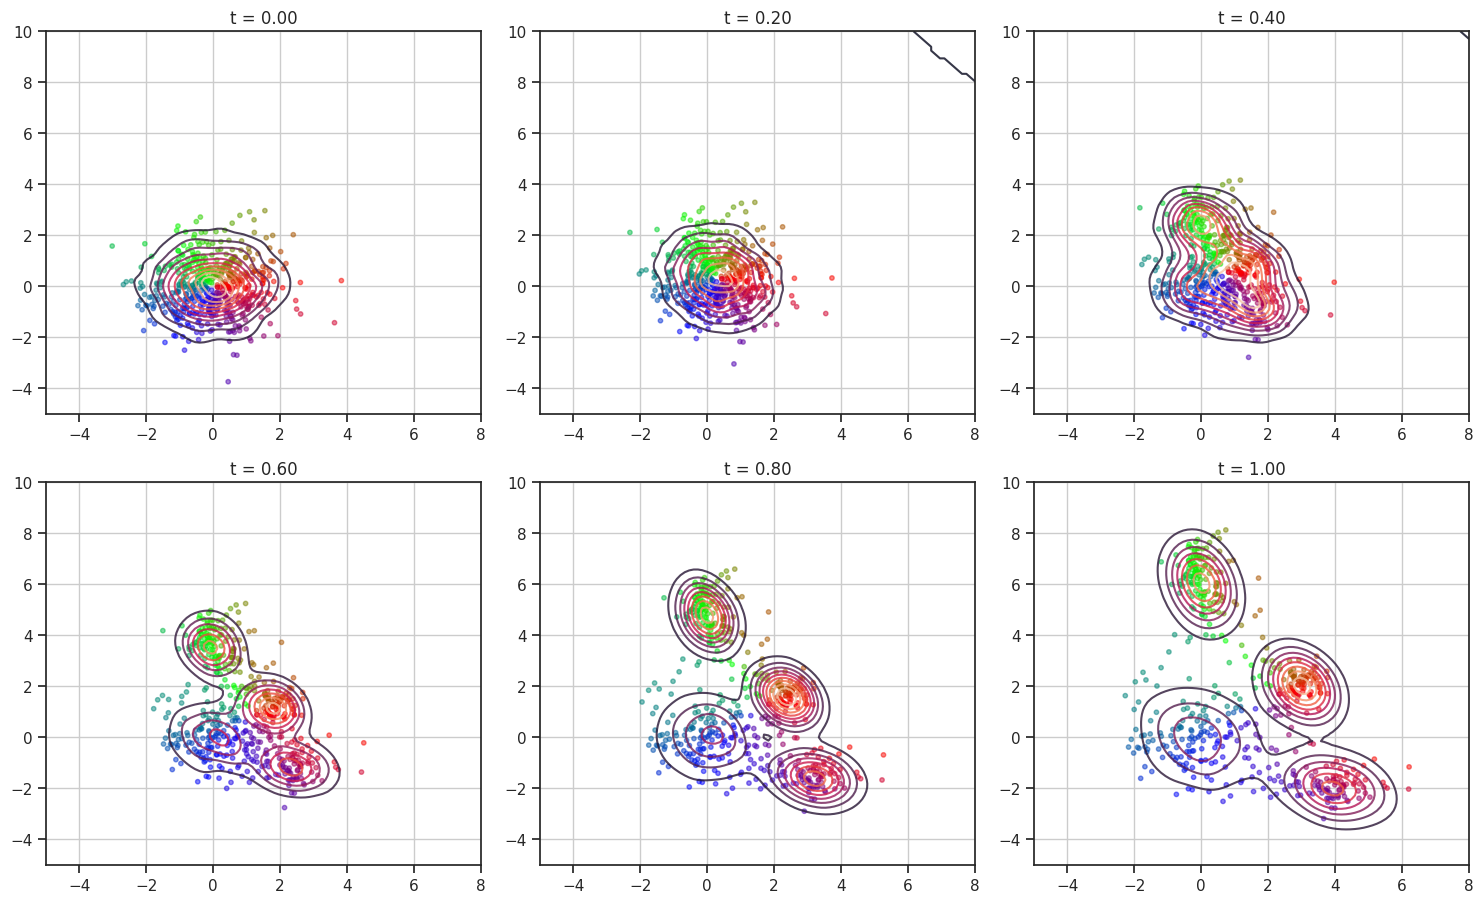

In [8]:
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
sns.set_theme(style="ticks", palette="pastel")

def get_angle_colors(positions):
    angles = np.arctan2(positions[:, 1], positions[:, 0])
    angles_deg = (np.degrees(angles) + 360) % 360
    colors = np.zeros((len(positions), 3))
    for i, angle in enumerate(angles_deg):
        segment = int(angle / 120)
        local_angle = angle - segment * 120
        if segment == 0:    # 0 degrees to 120 degrees (R->G)
            colors[i] = [1 - local_angle/120, local_angle/120, 0]
        elif segment == 1:  # 120 degrees to 240 degrees (G->B)
            colors[i] = [0, 1 - local_angle/120, local_angle/120]
        else:               # 240 degrees to 360° (B->R)
            colors[i] = [local_angle/120, 0, 1 - local_angle/120]

    return colors

# Desired time points to visualize
desired_times = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

# Determine indices in the trajectory corresponding to these times.
# We assume time_points is a 1D tensor of size n_steps.
time_np = time_points.detach().cpu().numpy()
n_steps = len(time_np)

# Get the index for each desired time: here we choose the index with minimum absolute difference.
indices = [np.argmin(np.abs(time_np - t_val)) for t_val in desired_times]

# Create subplots: We'll use 2 rows and 3 columns, one subplot per time.
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.ravel()  # flatten the 2D array for easier indexing

# Create grid for density visualization
xx, yy = np.mgrid[-5:8:100j, -5:10:100j]
positions = np.vstack([xx.ravel(), yy.ravel()])

for i, idx in enumerate(indices):
    ax = axes[i]
    # Get the samples at this time point: shape (batch, 2)
    x_t = trajectory[idx].detach().cpu().numpy()

    if i == 0:
        c = get_angle_colors(x_t)

    x_0 = mixture.sample(5000)
    t = time_np[idx]
    eps = np.random.randn(5000, 2)
    x_t_forward = t * x_0 + (1-t) * eps
    samples_ = x_t_forward

    # Compute KDE for visualization
    from scipy.stats import gaussian_kde
    kernel = gaussian_kde(samples_.T)
    density = np.reshape(kernel(positions).T, xx.shape)

    # Plot density contours
    ax.contour(xx, yy, density, levels=10, alpha=0.8)

    # Scatter plot: plot each sample as a point
    ax.scatter(x_t[:, 0], x_t[:, 1], alpha=0.5, s=10, color=c)
    ax.set_title(f"t = {time_np[idx]:.2f}")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()